In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [5]:
# Change RRVch (our target) to binary label for classification
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

# 1. Extract the baseline rows (one per participant)
baseline = df[df["Assmnt"] == "baseline"][["ID", "RRVscore"]]
baseline = baseline.rename(columns={"RRVscore": "Baseline_RRVscore"})

# 2. Keep only pstwash and endposttr rows
post = df[df["Assmnt"].isin(["pstwash", "endposttr"])]

# 3. Merge baseline RRVscore onto these rows
merged = post.merge(baseline, on="ID", how="left")

# merged now contains:
#   • all pstwash and endposttr rows
#   • baseline RRVscore appended for each participant

df = merged
df.drop(columns=[])


df.dropna(subset=["Baseline_RRVscore"])

df["Assmnt"] = df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

df = df[df["ID"] != 25]

df = df.drop(columns = ['RRVscore','RRV_Pgoal','RRV_Agoal','Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'])
df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


## MiniSOM

In [6]:
%pip install minisom

You should consider upgrading via the '/Users/hunliang/Desktop/HanEdu/hw/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
import math
import matplotlib.pyplot as plt

In [8]:
minisom_df = df.copy()
minisom_attr = minisom_df.drop(columns=['RRV_label'])
minisom_target = minisom_df['RRV_label']

sc = MinMaxScaler(feature_range=(0, 1))
features = sc.fit_transform(minisom_attr)
labels = minisom_target.values

print(f'Features shape: {features.shape}')
print(f'Labels shape: {labels.shape}')

Features shape: (121, 7)
Labels shape: (121,)


In [9]:
sigma = 1.5
lr = 0.5
n_features = features.shape[1]
n_samples = features.shape[0]

print(f"Number of samples: {n_samples}")
print(f"Square root of samples: {math.sqrt(n_samples)}")

map_size = 5 * math.sqrt(n_samples)
map_height = map_width = math.ceil(math.sqrt(map_size))

print(f'(map_height, map_width) = ({map_height}, {map_width})')
print(f'Number of features: {n_features}')

Number of samples: 121
Square root of samples: 11.0
(map_height, map_width) = (8, 8)
Number of features: 7


 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.18994649575579226


/Users/hunliang/Desktop/HanEdu/hw/venv/lib/python3.9/site-packages/minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


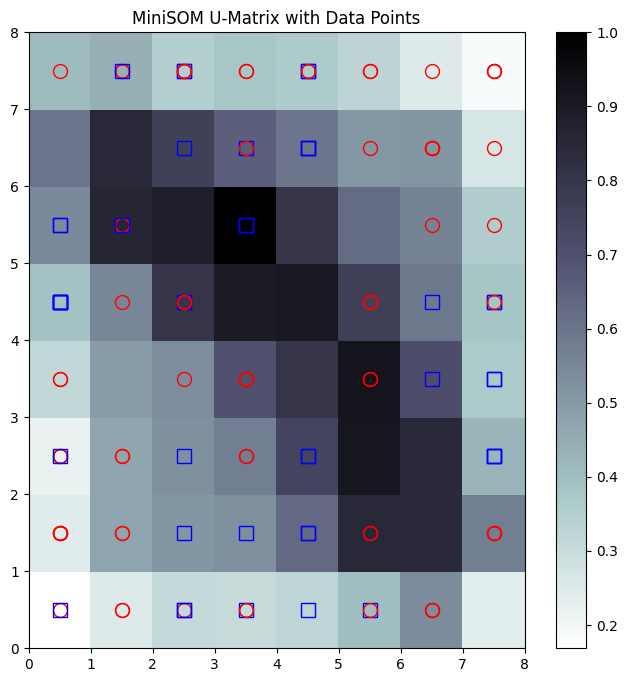

In [10]:
som = MiniSom(x=map_height, y=map_width, input_len=n_features, sigma=sigma, learning_rate=lr,
			neighborhood_function='gaussian', random_seed=123)
som.pca_weights_init(features)
som.train(data=features, num_iteration=1000, verbose=True)

# visualize the SOM with U-matrix
plt.figure(figsize=(map_height, map_width))
u_matrix = som.distance_map().T
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar()

markers = ['o', 's']  # 0: No increase, 1: Increase in motivation
colors = ['r', 'b']   # Red for 0, Blue for 1
class_names = ['No_Increase', 'Increase_Motiv']

for feature, label in zip(features, labels):
	w = som.winner(feature)
	plt.plot(w[0] + 0.5, w[1] + 0.5,
			markers[label], markeredgecolor=colors[label],
			markerfacecolor='None', markersize=10, markeredgewidth=1)

plt.title('MiniSOM U-Matrix with Data Points')
plt.show()

In [11]:
# get winner coordinates for each data point
winners = [som.winner(x) for x in features]

# create cluster labels based on winner coordinates
unique_coords = {coord: idx for idx, coord in enumerate(set(winners))}
cluster_labels = np.array([unique_coords[w] for w in winners])

print(f'Number of unique clusters: {len(unique_coords)}')
print(f'Cluster labels: {cluster_labels}')
print(f'Cluster distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster, count in zip(unique, counts):
	print(f'  Cluster {cluster}: {count} samples')

Number of unique clusters: 51
Cluster labels: [45 26 12 47 10 31  1  2 10 33 22 36 38 48 22 28  8  4 27 20 26 36 38 16
 20 26 28  8 36 41 44  7 48 22 36 41  4 16  6 22 12 47 32 22 37 29 48 25
 44 29 13  7 28 25 12 47 48  7 13 40  2 41 18 12 18  6 34 40 19 44  9 39
  4 29 28 42 44 26 28  7  0 13 39 37 26 16 21 15  5 46  5 23 17  3 17 21
 34 14 24  3 17  3 17 11 15 11 24 31 35 46 46 50 35 11 24 30 43 49 24  3
 17]
Cluster distribution:
  Cluster 0: 1 samples
  Cluster 1: 1 samples
  Cluster 2: 2 samples
  Cluster 3: 4 samples
  Cluster 4: 3 samples
  Cluster 5: 2 samples
  Cluster 6: 2 samples
  Cluster 7: 4 samples
  Cluster 8: 2 samples
  Cluster 9: 1 samples
  Cluster 10: 2 samples
  Cluster 11: 3 samples
  Cluster 12: 4 samples
  Cluster 13: 3 samples
  Cluster 14: 1 samples
  Cluster 15: 2 samples
  Cluster 16: 3 samples
  Cluster 17: 5 samples
  Cluster 18: 2 samples
  Cluster 19: 1 samples
  Cluster 20: 2 samples
  Cluster 21: 2 samples
  Cluster 22: 5 samples
  Cluster 23: 1 samp